In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("fraud_detection_credit_card_small.csv")

In [ ]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,merch_long,is_fraud,merch_zipcode,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Transaction_Time,Customer_Age,Payment_Method,Loyalty_Points_Earned
0,1045211,2020-03-09 15:09:26,577588686219,fraud_Towne LLC,misc_pos,194.51,James,Strickland,M,25454 Leonard Lake,...,-78.865012,0,15909.0,Electronics,In-store,6,11:10,69,Debit Card,332
1,547406,2019-08-22 15:49:01,30376238035123,fraud_Friesen Ltd,health_fitness,52.32,Cynthia,Davis,F,7177 Steven Forges,...,-123.636337,0,NaN,Entertainment,Online,8,20:42,47,Mobile Payment,476
2,110142,2019-03-04 01:34:16,4658490815480264,fraud_Mohr Inc,shopping_pos,6.53,Tara,Richards,F,4879 Cristina Station,...,-78.898190,0,15961.0,Restaurants,Online,3,05:19,69,Debit Card,100
3,1285953,2020-06-16 20:04:38,3514897282719543,fraud_Gaylord-Powlowski,home,7.33,Steven,Faulkner,M,841 Cheryl Centers Suite 115,...,-76.542384,0,NaN,Restaurants,Online,4,06:12,31,Mobile Payment,460
4,271705,2019-05-14 05:54:48,6011381817520024,"fraud_Christiansen, Goyette and Schamberger",gas_transport,64.29,Kristen,Allen,F,8619 Lisa Manors Apt. 871,...,-104.092324,0,82082.0,Clothing,In-store,5,01:01,44,Mobile Payment,372


In [ ]:
df.shape

(100000, 31)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   100000 non-null  int64  
 1   trans_date_trans_time        100000 non-null  object 
 2   cc_num                       100000 non-null  int64  
 3   merchant                     100000 non-null  object 
 4   category                     100000 non-null  object 
 5   amt                          100000 non-null  float64
 6   first                        100000 non-null  object 
 7   last                         100000 non-null  object 
 8   gender                       100000 non-null  object 
 9   street                       100000 non-null  object 
 10  city                         100000 non-null  object 
 11  state                        100000 non-null  object 
 12  zip                          100000 non-null  int64  
 13  

In [ ]:
df.shape

(100000, 31)

In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
        r = 6371 # Earth radius in kilometers
        phi1, phi2 = np.radians(lat1), np.radians(lat2)
        delta_phi = np.radians(lat2 - lat1)
        delta_lambda = np.radians(lon2 - lon1)
        a = np.sin(delta_phi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda/2)**2
        return 2 * r * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df['distance_km'] = haversine_distance(df['lat'], df['long'], df['merch_lat'], df['merch_long'])

In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

In [ ]:
df.drop(columns=['Unnamed: 0', 'cc_num', 'merchant', 'first', 'last', 'street', 'city','state', 'zip', 'job', 'dob', 'trans_num', 'unix_time', 'merch_zipcode',
        'Transaction_Time', 'trans_date_trans_time', 'lat', 'long', 'merch_lat', 'merch_long'],inplace = True)

In [ ]:
df.columns

Index(['category', 'amt', 'gender', 'city_pop', 'is_fraud',
       'Merchant_Category', 'Transaction_Type', 'Customer_Satisfaction_Score',
       'Customer_Age', 'Payment_Method', 'Loyalty_Points_Earned',
       'distance_km', 'trans_hour'],
      dtype='object')

In [ ]:
df.head()

,category,amt,gender,city_pop,is_fraud,Merchant_Category,Transaction_Type,Customer_Satisfaction_Score,Customer_Age,Payment_Method,Loyalty_Points_Earned,distance_km,trans_hour
0,misc_pos,194.51,M,972,0,Electronics,In-store,6,69,Debit Card,332,54.336119,15
1,health_fitness,52.32,F,217,0,Entertainment,Online,8,47,Mobile Payment,476,66.060865,15
2,shopping_pos,6.53,F,184,0,Restaurants,Online,3,69,Debit Card,100,94.386045,1
3,home,7.33,M,10717,0,Restaurants,Online,4,31,Mobile Payment,460,109.251290,20
4,gas_transport,64.29,F,635,0,Clothing,In-store,5,44,Mobile Payment,372,67.501516,5


In [ ]:
categorical_cols = ['category', 'gender', 'Merchant_Category', 'Transaction_Type', 'Payment_Method']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True,dtype=int)

In [ ]:
df.head()

,amt,city_pop,is_fraud,Customer_Satisfaction_Score,Customer_Age,Loyalty_Points_Earned,distance_km,trans_hour,category_food_dining,category_gas_transport,...,category_shopping_pos,category_travel,gender_M,Merchant_Category_Electronics,Merchant_Category_Entertainment,Merchant_Category_Groceries,Merchant_Category_Restaurants,Transaction_Type_Online,Payment_Method_Debit Card,Payment_Method_Mobile Payment
0,194.51,972,0,6,69,332,54.336119,15,0,0,...,0,0,1,1,0,0,0,0,1,0
1,52.32,217,0,8,47,476,66.060865,15,0,0,...,0,0,0,0,1,0,0,1,0,1
2,6.53,184,0,3,69,100,94.386045,1,0,0,...,1,0,0,0,0,0,1,1,1,0
3,7.33,10717,0,4,31,460,109.251290,20,0,0,...,0,0,1,0,0,0,1,1,0,1
4,64.29,635,0,5,44,372,67.501516,5,0,1,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
df.isnull().sum()

,0
amt,0
city_pop,0
is_fraud,0
Customer_Satisfaction_Score,0
Customer_Age,0
Loyalty_Points_Earned,0
distance_km,0
trans_hour,0
category_food_dining,0
category_gas_transport,0


In [ ]:
X = df.drop(columns="is_fraud")

In [ ]:
y = df["is_fraud"]

In [ ]:
X.head()

,amt,city_pop,Customer_Satisfaction_Score,Customer_Age,Loyalty_Points_Earned,distance_km,trans_hour,category_food_dining,category_gas_transport,category_grocery_net,...,category_shopping_pos,category_travel,gender_M,Merchant_Category_Electronics,Merchant_Category_Entertainment,Merchant_Category_Groceries,Merchant_Category_Restaurants,Transaction_Type_Online,Payment_Method_Debit Card,Payment_Method_Mobile Payment
0,194.51,972,6,69,332,54.336119,15,0,0,0,...,0,0,1,1,0,0,0,0,1,0
1,52.32,217,8,47,476,66.060865,15,0,0,0,...,0,0,0,0,1,0,0,1,0,1
2,6.53,184,3,69,100,94.386045,1,0,0,0,...,1,0,0,0,0,0,1,1,1,0
3,7.33,10717,4,31,460,109.251290,20,0,0,0,...,0,0,1,0,0,0,1,1,0,1
4,64.29,635,5,44,372,67.501516,5,0,1,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(80000, 28)
(20000, 28)
(80000,)
(20000,)


In [ ]:
std = StandardScaler()
x_train_scaled = std.fit_transform(x_train)
x_test_scaled = std.transform(x_test)

In [ ]:
X.shape

(100000, 28)

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
model = Sequential()
model.add(Dense(3,activation='sigmoid',input_dim = 28 ))
model.add(Dense(1,activation="sigmoid"))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 3)              │            87 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91 (364.00 B)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss="binary_crossentropy",optimizer="Adam")

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# 1. Calculate the proper weights based on your training data
weights = class_weight.compute_class_weight(
  'balanced',
        classes=np.unique(y_train),
        y=y_train
    )
class_weights_dict = dict(enumerate(weights))

print(f"Applying Class Weights: {class_weights_dict}")

Applying Class Weights: {0: np.float64(0.5030307603309943), 1: np.float64(82.98755186721992)}


In [ ]:
    history = model.fit(
        x_train_scaled,
        y_train,
        epochs=20,           # (use whatever epochs you had)
        batch_size=32,       # (use whatever batch size you had)
        validation_split=0.2,
        class_weight=class_weights_dict  # <--- THIS IS THE MAGIC FIX
    )

Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.8354 - val_loss: 0.1462
Epoch 2/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.5403 - val_loss: 0.2628
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.4714 - val_loss: 0.3291
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.4408 - val_loss: 0.3074
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.4184 - val_loss: 0.3232
Epoch 6/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3997 - val_loss: 0.2998
Epoch 7/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3848 - val_loss: 0.3037
Epoch 8/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3717 - val_loss: 0.2906
Epoch 9/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3603 - val_loss: 0.2974
Epoch 10/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.3500 - val_loss: 0.2940
Epoch 11/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 0.3416 - val_loss: 0.2824
Epoch 12/20
2000/2000 ━━━━━━

In [ ]:
pred = model.predict(x_test_scaled)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
pred

array([[0.38659778],
       [0.0872825 ],
       [0.326749  ],
       ...,
       [0.33483037],
       [0.22048774],
       [0.5263932 ]], dtype=float32)

In [ ]:
y_pred = np.where(pred>0.5,1,0)

In [ ]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

accuracy_score(y_test,y_pred)

0.93695

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     19884
           1       0.21      0.72      0.32       116

    accuracy                           0.98     20000
   macro avg       0.60      0.85      0.66     20000
weighted avg       0.99      0.98      0.99     20000


--- Confusion Matrix ---


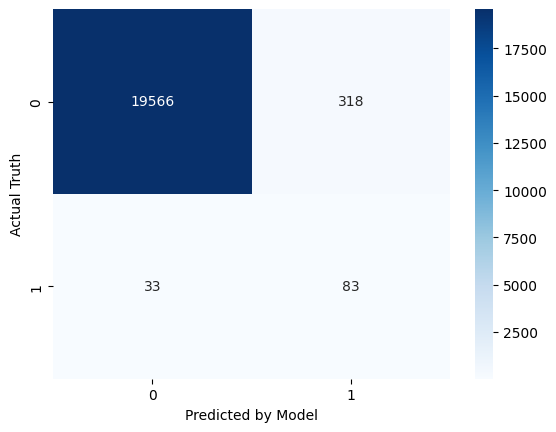

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_probs = model.predict(x_test_scaled) # Or whatever you named your test data
y_pred = (y_pred_probs > 0.80).astype(int)

    # 1. Print the Classification Report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

    # 2. Plot the Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted by Model')
plt.ylabel('Actual Truth')
plt.show()

In [ ]:
model.save("fraud_detection_model.keras")
print("model saved")

model saved


In [ ]:
import joblib

joblib.dump(std, "scaler.pkl")

['scaler.pkl']